In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib


# 1. LOAD DATASET
df = pd.read_csv("../data/dataset.csv", skipinitialspace=True)
print("Dataset gốc:", df.shape)
print(df.head())


# 2. CHUẨN HÓA NHÃN STAGE
df['Stage'] = df['Stage'].str.upper()

# Tạo nhãn nhị phân: BENIGN hoặc NORMAL → 0 | còn lại → 1
df['Label'] = df['Stage'].apply(lambda x: 0 if x in ['BENIGN', 'NORMAL'] else 1)

# 3. LOẠI BỎ CÁC CỘT OBJECT TRONG FEATURES (TRỪ LABEL)
object_cols = df.select_dtypes(include=['object']).columns.tolist()

# Stage là object → xóa, không dùng nữa
if 'Stage' in object_cols:
    object_cols.remove('Stage')

print("\nCác cột object bị loại khỏi X:", object_cols)

# Xóa mọi cột object và xóa thêm Stage
df_clean = df.drop(columns=object_cols + ['Stage'])

print("\nDataset sau khi loại bỏ object columns:", df_clean.shape)


Dataset gốc: (86691, 85)
                                  Flow ID        Src IP  Src Port  \
0                   8.0.6.4-8.6.0.1-0-0-0       8.6.0.1         0   
1  192.168.3.10-239.2.11.71-53569-8662-17  192.168.3.10     53569   
2        255.255.255.255-0.0.0.0-67-68-17       0.0.0.0        68   
3  192.168.3.30-192.168.3.31-40504-9200-6  192.168.3.30     40504   
4              0.87.248.248-3.0.0.0-0-0-0  0.87.248.248         0   

            Dst IP  Dst Port  Protocol               Timestamp  Flow Duration  \
0          8.0.6.4         0         0  15/07/2019 01:55:21 PM      119998944   
1      239.2.11.71      8662        17  15/07/2019 01:55:22 PM      109235816   
2  255.255.255.255        67        17  15/07/2019 01:55:22 PM      119764062   
3     192.168.3.31      9200         6  15/07/2019 01:55:23 PM      117030424   
4          3.0.0.0         0         0  15/07/2019 01:55:58 PM      119999703   

   Total Fwd Packet  Total Bwd packets  ...    Active Mean     Active Std

In [3]:
# 4. CHUẨN BỊ X, y

X = df_clean.drop(columns=['Label'])
y = df_clean['Label']

print("\nClasses Label:", y.value_counts().to_dict())

# 5. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)


Classes Label: {0: 63712, 1: 22979}

Train size: (69352, 79)
Test size: (17339, 79)


In [5]:
from imblearn.over_sampling import SMOTE

# 5b. ÁP DỤNG SMOTE CHO TRAINING DATA
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nTrain size trước SMOTE:", X_train.shape)
print("Train size sau SMOTE:", X_train_res.shape)


Train size trước SMOTE: (69352, 79)
Train size sau SMOTE: (101938, 79)


In [6]:
# 6. TRAIN RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train_res, y_train_res)
print("\n🎯 Model training hoàn tất")

# 7. DỰ ĐOÁN + ĐÁNH GIÁ
y_pred = rf.predict(X_test)

print("\n=== Accuracy ===")
print(accuracy_score(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['BENIGN(0)', 'APT(1)']))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

# 8. FEATURE IMPORTANCE
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== TOP 20 FEATURE IMPORTANCE ===")
print(feature_importances.head(20))

# 9. LƯU MÔ HÌNH 
model_path = "../models/rf_model.pkl"
joblib.dump(rf, model_path)

print(f"\n✅ Mô hình Random Forest đã được lưu vào: {model_path}")


🎯 Model training hoàn tất

=== Accuracy ===
0.986735105830786

=== Classification Report ===
              precision    recall  f1-score   support

   BENIGN(0)       0.99      0.99      0.99     12743
      APT(1)       0.97      0.99      0.98      4596

    accuracy                           0.99     17339
   macro avg       0.98      0.99      0.98     17339
weighted avg       0.99      0.99      0.99     17339


=== Confusion Matrix ===
[[12581   162]
 [   68  4528]]

=== TOP 20 FEATURE IMPORTANCE ===
                  Feature  Importance
0                Src Port    0.126318
1                Dst Port    0.074595
68     Bwd Init Win Bytes    0.057218
17         Flow Packets/s    0.054420
18          Flow IAT Mean    0.050138
39          Bwd Packets/s    0.044820
38          Fwd Packets/s    0.042703
31            Bwd IAT Min    0.035709
13  Bwd Packet Length Min    0.032273
20           Flow IAT Max    0.026987
37      Bwd Header Length    0.025367
36      Fwd Header Length    0.

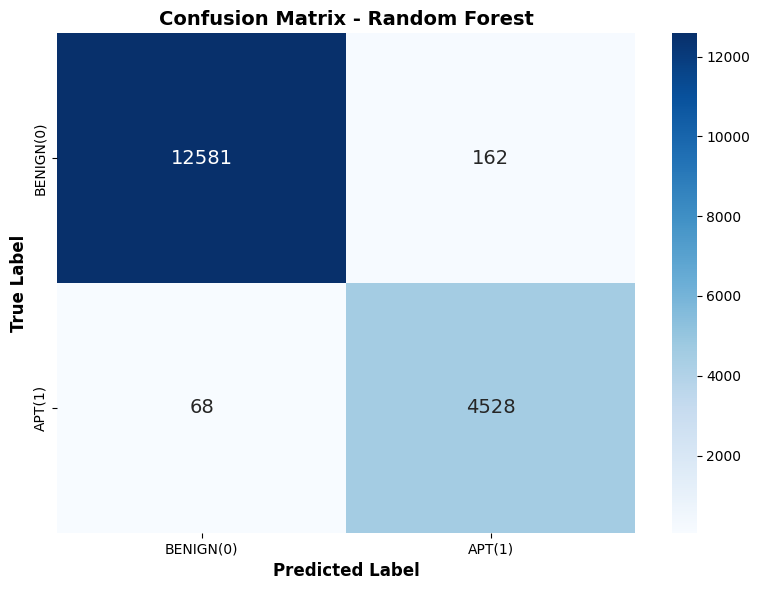

In [7]:
# 10. VISUALIZE CONFUSION MATRIX
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))

# Tính confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Vẽ heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['BENIGN(0)', 'APT(1)'],
            yticklabels=['BENIGN(0)', 'APT(1)'],
            ax=ax, annot_kws={'size': 14})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


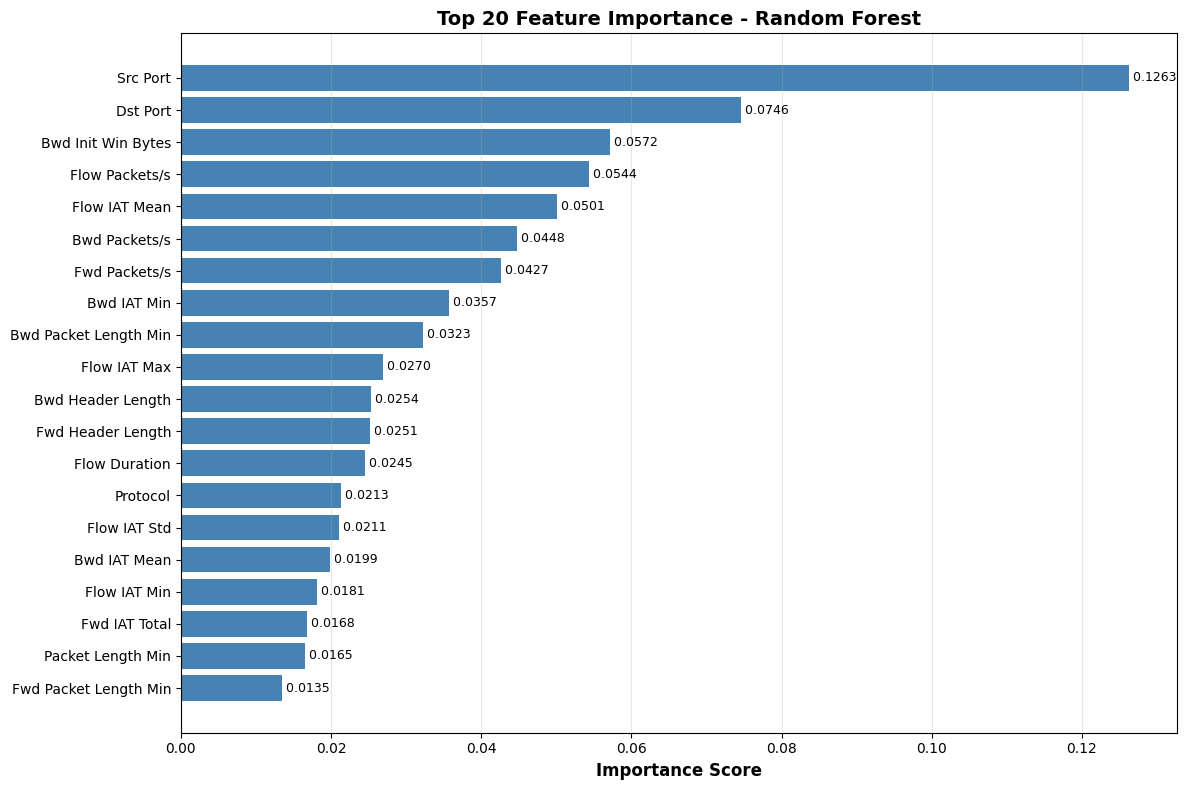

In [8]:
# 11. VISUALIZE TOP 20 FEATURE IMPORTANCE
fig, ax = plt.subplots(figsize=(12, 8))

top_20_features = feature_importances.head(20)

# Vẽ bar chart
bars = ax.barh(range(len(top_20_features)), top_20_features['Importance'].values, color='steelblue')

# Thêm giá trị trên mỗi bar
for i, (idx, row) in enumerate(top_20_features.iterrows()):
    ax.text(row['Importance'], i, f" {row['Importance']:.4f}", va='center', fontsize=9)

ax.set_yticks(range(len(top_20_features)))
ax.set_yticklabels(top_20_features['Feature'].values, fontsize=10)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Feature Importance - Random Forest', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
